# Baseline regressors on the linear_op dataset: MAPE is not enough

Per (op, TP) Random Forest and XGBoost baselines (`baseline_rf_xgb.py`, sealed random-geometry shape-level split,
feature `num_tokens`, label `time_stats.<op>.median`). This notebook looks past the mean error at the **tails**:
median, p95, p99 and max absolute percentage error, where in `num_tokens` they occur, and what they are in microseconds.

**Tiers used:** train (refit) and test (all numbers). The holdout is never read here.

**How to read the three views per op**

1. **ECDF of |error| %** (one panel per TP, both models). Every quantile is on the curve: read p95 / p99 where the
   dashed lines cross, the max is the right end. Two curves compare models at *every* quantile, not one number.
2. **Signed error vs `num_tokens`.** Where the tail lives: hipBLASLt tile-step windows are shaded, sub-10 µs labels
   (instrument floor, ±3-5 µs) are hollow markers. A bias shows as a one-sided cloud.
3. **Absolute error in µs vs `num_tokens`.** The simulator sums per-layer times, so a 10 % miss on a 7 µs label
   (0.7 µs) and a 3 % miss at 16k tokens (15 µs) are not the same problem. Relative and absolute tails rank pairs differently.

**Cautions.** With ~499 test points p99 is roughly the 5th-worst point: real, but noisy. The label's own relative
standard error is 0.3-1.5 % per regressor, so errors at that level are measurement, not model.

In [1]:
import json, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

HERE = Path.cwd()
while not (HERE / "splits" / "manifest.json").exists():   # allow launching from the repo root
    cand = [p for p in HERE.rglob("regressor_bench/splits/manifest.json")]
    if cand: HERE = cand[0].parents[1]; break
    HERE = HERE.parent
sys.path.insert(0, str(HERE.parent))
from regressor_bench.dataset import load_raw, tidy, DEFAULT_CSV
from regressor_bench.splits import load_split
from regressor_bench.metrics import ape, INSTRUMENT_FLOOR_MS
from regressor_bench.baseline_rf_xgb import FITTERS, CLIFFS, in_cliff
from regressor_bench.report import SERIES, INK, INK2, MUTED, GRID, BASELINE, SURFACE
%matplotlib inline
# (after the report import: that module selects the Agg backend for file output; the magic switches back)

RESULTS = HERE / "results" / "baseline_rf_xgb"
CSV = HERE.parents[2] / DEFAULT_CSV if not Path(DEFAULT_CSV).exists() else Path(DEFAULT_CSV)
MODELS = {"rf": ("Random Forest", SERIES[0]), "xgb": ("XGBoost", SERIES[1])}
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
print("package:", HERE); print("results:", RESULTS); print("csv:", CSV)

package: /home/dn/Frontier-drivenets/.claude/worktrees/regressor-bench/profiling_knowledge/qwen3_30b_a3b_mi355x_profiling/regressor_bench
results: /home/dn/Frontier-drivenets/.claude/worktrees/regressor-bench/profiling_knowledge/qwen3_30b_a3b_mi355x_profiling/regressor_bench/results/baseline_rf_xgb
csv: /home/dn/Frontier-drivenets/.claude/worktrees/regressor-bench/data/local_datasets/mi355x/qwen3-a3b-30b-moe/linear_op/2026-09-23_0949_dense_workbacklog_settle8/linear_op.csv


In [2]:
t = tidy(load_raw(CSV))
split = load_split(HERE / "splits", "random", include_holdout=False)     # train + test token lists only
assert set(split) == {"train", "test"}
results = pd.read_csv(RESULTS / "results.csv")
print(f"train tokens {len(split['train'])}, test tokens {len(split['test'])}, regressors {results[['op','tp']].drop_duplicates().shape[0]}")

train tokens 2496, test tokens 499, regressors 15


## Per-row test predictions

The run stored metrics, not rows. The winning configuration of each (op, TP, model) is refit here from the recorded
hyper-parameters (deterministic seeds), and the refit MAPE is asserted against `results.csv` before anything is plotted.
Runs made after this notebook was written also save `test_predictions.csv`, which is used directly when present.

In [3]:
def _subset(op, tp, tokens):
    g = t[(t.op == op) & (t.tp == tp) & t.num_tokens.isin(tokens)].sort_values("num_tokens")
    return g[["num_tokens"]].to_numpy(float), g["y"].to_numpy(float), g["num_tokens"].to_numpy()

saved = RESULTS / "test_predictions.csv"
if saved.exists():
    preds = pd.read_csv(saved); preds = preds[preds.tier == "test"].drop(columns="tier")
    print("using saved test_predictions.csv")
else:
    frames = []
    for r in results.itertuples(index=False):
        Xtr, ytr, ttr = _subset(r.op, r.tp, split["train"]); Xte, yte, tte = _subset(r.op, r.tp, split["test"])
        params = json.loads(r.best_params)
        if r.model == "xgb":
            params["n_estimators"] = int(r.xgb_best_iteration)       # early stopping already resolved in the run
            from xgboost import XGBRegressor
            m = XGBRegressor(objective="reg:squarederror", random_state=0, n_jobs=1, verbosity=0, **params).fit(Xtr, ytr)
        else:
            m = FITTERS["rf"](params, Xtr, ytr, ttr)
        frames.append(pd.DataFrame(dict(op=r.op, tp=r.tp, model=r.model, num_tokens=tte, y=yte, pred=m.predict(Xte))))
    preds = pd.concat(frames, ignore_index=True)
    print("refit 30 winners")

preds["ape"] = ape(preds.y, preds.pred)
preds["signed_pct"] = (preds.pred - preds.y) / preds.y * 100
preds["abs_err_us"] = (preds.pred - preds.y).abs() * 1e3
preds["cliff"] = in_cliff(preds.num_tokens.to_numpy())
preds["sub10us"] = preds.y < INSTRUMENT_FLOOR_MS

chk = preds.groupby(["op", "tp", "model"]).ape.mean().rename("refit_mape").reset_index().merge(results[["op", "tp", "model", "test_mape"]])
chk["diff"] = (chk.refit_mape - chk.test_mape).abs()
assert chk["diff"].max() < 1e-6, chk.sort_values("diff", ascending=False).head()
print("refit reproduces results.csv test MAPE for all 30 (max |diff| = %.2e)" % chk["diff"].max())

refit 30 winners
refit reproduces results.csv test MAPE for all 30 (max |diff| = 4.44e-16)


## Tail table

`argmax_tokens` is the `num_tokens` of the worst test point; `max_abs_us` is the worst absolute miss in microseconds.

In [4]:
def tails(g):
    i = g.ape.idxmax()
    return pd.Series({"n": len(g), "MAPE": g.ape.mean(), "MdAPE": g.ape.median(), "p95": g.ape.quantile(.95),
                      "p99": g.ape.quantile(.99), "max": g.ape.max(), "argmax_tokens": int(g.loc[i, "num_tokens"]),
                      "y_at_max_us": g.loc[i, "y"] * 1e3, "bias_%": g.signed_pct.mean(),
                      "p95_abs_us": g.abs_err_us.quantile(.95), "max_abs_us": g.abs_err_us.max()})

tab = preds.groupby(["op", "tp", "model"]).apply(tails).reset_index()
tab["n"] = tab.n.astype(int)
show = tab.pivot(index=["op", "tp"], columns="model", values=["MAPE", "p95", "p99", "max", "argmax_tokens", "max_abs_us"])
show = show.reindex(columns=["MAPE", "p95", "p99", "max", "argmax_tokens", "max_abs_us"], level=0)
show.round(2).style.background_gradient(subset=[c for c in show.columns if c[0] in ("MAPE", "p95", "p99", "max")], cmap="Blues", axis=None)

In [5]:
# same table, long form, sortable
tab.sort_values(["model", "p99"], ascending=[True, False]).round(2)

,op,tp,model,n,MAPE,MdAPE,p95,p99,max,argmax_tokens,y_at_max_us,bias_%,p95_abs_us,max_abs_us
6,attn_post_proj,8,rf,499,1.32,0.94,3.62,7.22,17.86,128.0,11.32,-0.04,0.99,3.24
24,emb,1,rf,499,1.45,1.04,4.03,6.62,17.05,18.0,6.24,-0.10,0.52,1.44
8,attn_pre_proj,1,rf,499,1.33,0.94,2.84,6.27,83.97,1.0,11.76,0.12,6.84,23.30
12,attn_pre_proj,4,rf,499,1.20,0.86,2.68,5.56,59.31,1.0,11.36,0.11,2.95,15.63
0,attn_post_proj,1,rf,499,1.35,1.03,3.18,5.31,34.94,1.0,7.32,-0.02,2.19,7.27
2,attn_post_proj,2,rf,499,1.42,1.16,3.41,5.23,13.88,1.0,6.16,0.12,1.75,7.55
4,attn_post_proj,4,rf,499,1.24,1.04,3.13,4.53,8.67,4.0,6.24,0.10,0.97,3.47
26,input_layernorm,1,rf,499,1.24,0.98,3.03,4.30,8.23,13840.0,75.76,-0.07,1.43,6.23
18,attn_rope,2,rf,499,1.33,1.16,3.06,3.92,5.30,997.0,7.92,0.15,0.55,0.95
14,attn_pre_proj,8,rf,499,1.32,0.90,2.83,3.88,93.86,1.0,10.92,0.04,1.64,10.25


### What the table says (first run, 2026-09-23)

* **The max error is one point: `num_tokens = 1`.** The random draw put the grid's minimum into the test tier, so for
  the eight GEMM regressors the worst miss is 35-99 % at 1 token. The label there is a different kernel regime
  (attn_pre_proj TP8: 10.9 µs at 1 token vs 16.7 at 2 and ~22 from 5 on; attn_post_proj TP1: 7.3 vs 13.8 at 3), and 1
  is below the training range, so a tree predicts the 2-8-token plateau. That is extrapolation off the grid's edge,
  not a tail of the interpolation error. For the simulator it matters only if decode steps of exactly one token per
  forward are predicted; otherwise read `p99`, not `max`.
* **Excluding that point, p99 is 3.5-7 % for RF and 4-19 % for XGBoost.** XGBoost's tail is worse on every attn_post_proj
  pair (p99 12-19 %, p95 up to 11 % at TP8) and on the two norms; the two models are equivalent on attn_rope.
* **In microseconds the tails are small.** RF's p95 absolute error is 0.2-7 µs; the largest single miss is 23 µs
  (attn_pre_proj TP1, again the 1-token point). The relative tail is dominated by small labels near the instrument floor.
* **Bias is < 0.4 % everywhere**, so the errors are scatter, not a systematic offset.

## View 1: ECDF of |error| %, per op (panels = TP)

Dashed verticals mark p95 and p99 of each model; the curve's right end is the max. Log x-axis so the 1 % body
and the 10 %+ tail are both legible.

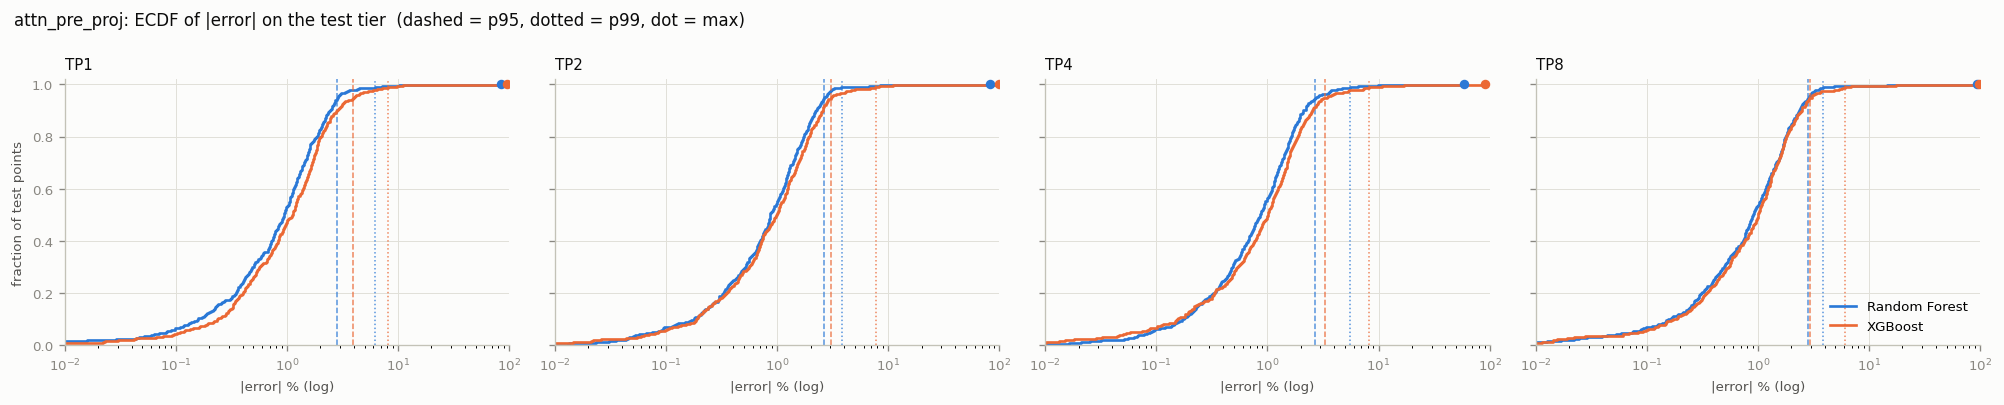

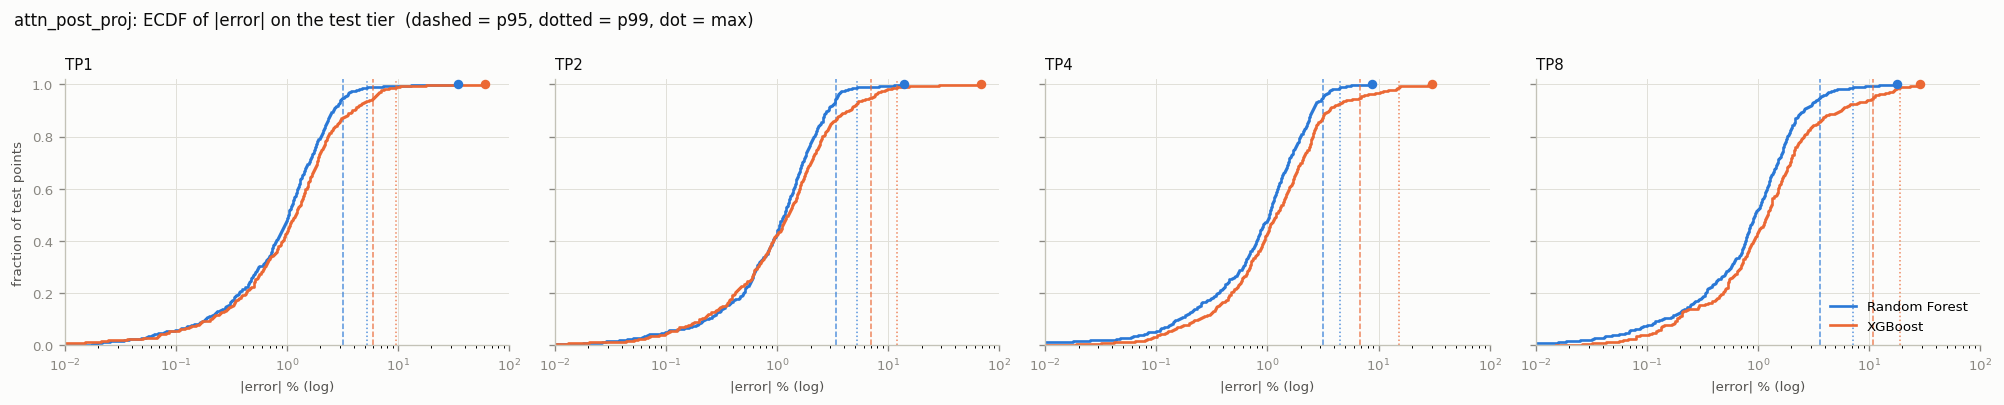

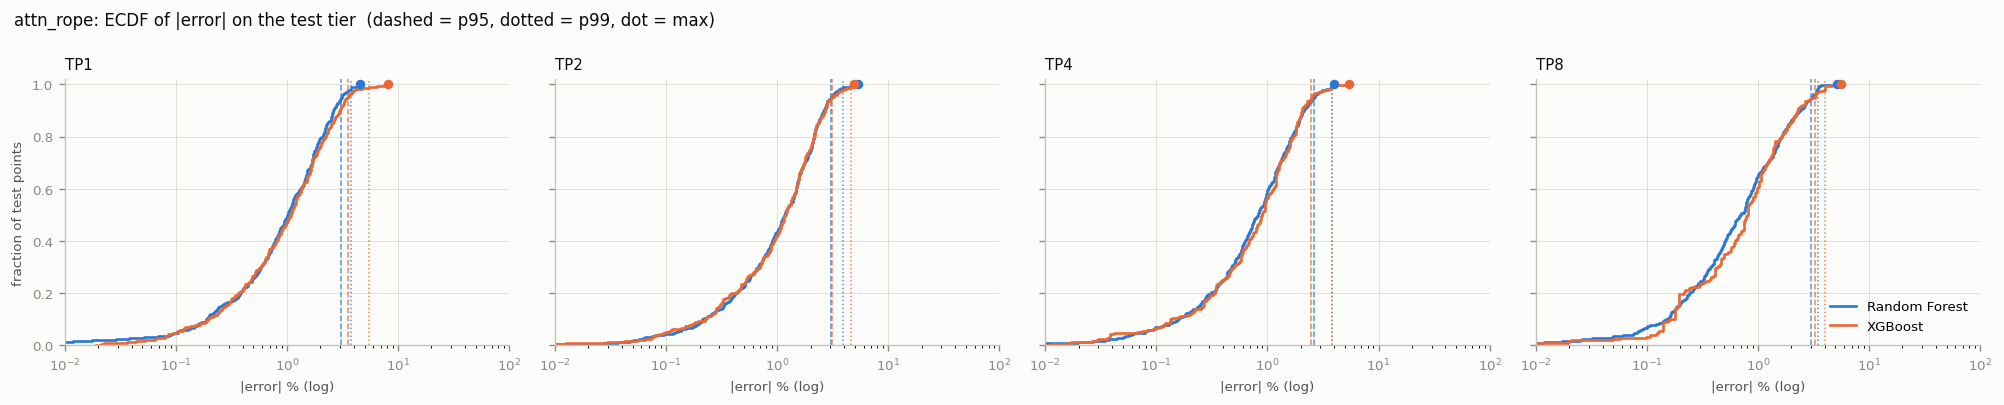

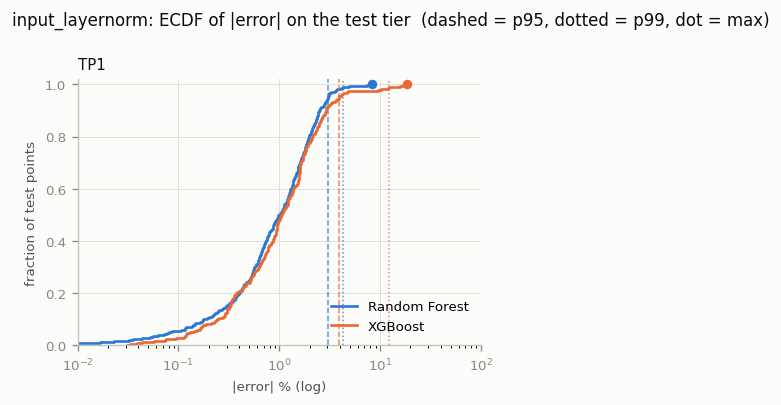

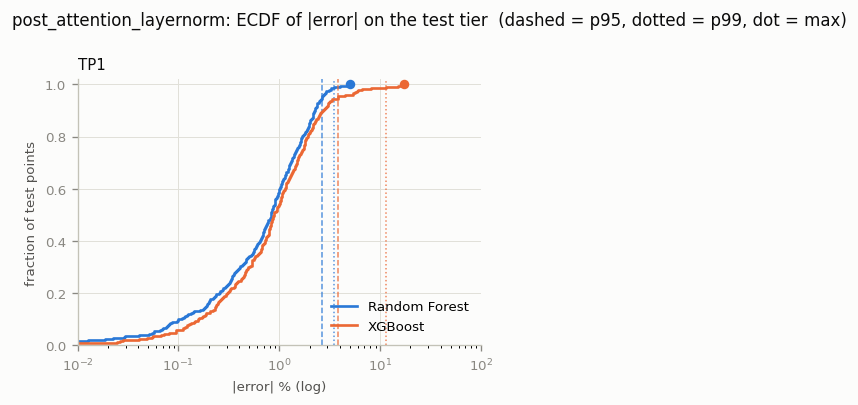

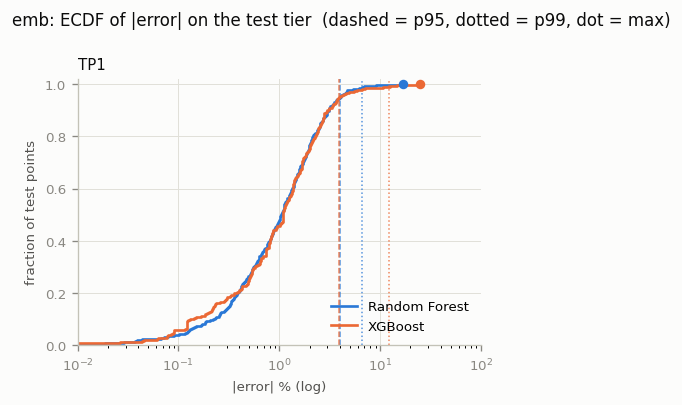

In [6]:
def style(ax):
    ax.set_facecolor(SURFACE)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color(BASELINE)
    ax.tick_params(colors=MUTED, labelsize=8); ax.grid(True, color=GRID, lw=.6); ax.set_axisbelow(True)

def ecdf_panel(ax, g, label, color):
    x = np.sort(g.ape.to_numpy()); y = np.arange(1, len(x) + 1) / len(x)
    ax.step(x, y, where="post", lw=1.6, color=color, label=label)
    for q, ls in ((.95, "--"), (.99, ":")):
        ax.axvline(np.quantile(x, q), color=color, lw=.9, ls=ls, alpha=.8)
    ax.scatter([x[-1]], [1.0], s=22, color=color, zorder=3)

def ecdf_op(op):
    tps = sorted(preds[preds.op == op].tp.unique())
    fig, axes = plt.subplots(1, len(tps), figsize=(4.2 * len(tps), 3.4), dpi=120, sharey=True, squeeze=False)
    fig.patch.set_facecolor(SURFACE)
    for ax, tp in zip(axes[0], tps):
        style(ax)
        for m, (name, color) in MODELS.items():
            g = preds[(preds.op == op) & (preds.tp == tp) & (preds.model == m)]
            ecdf_panel(ax, g, name, color)
        ax.set_xscale("log"); ax.set_xlim(0.01, 100); ax.set_ylim(0, 1.02)
        ax.set_title(f"TP{tp}", loc="left", fontsize=9, color=INK); ax.set_xlabel("|error| % (log)", fontsize=8, color=INK2)
    axes[0][0].set_ylabel("fraction of test points", fontsize=8, color=INK2)
    axes[0][-1].legend(frameon=False, fontsize=8, loc="lower right")
    fig.suptitle(f"{op}: ECDF of |error| on the test tier  (dashed = p95, dotted = p99, dot = max)", x=.01, ha="left", fontsize=10, color=INK)
    fig.tight_layout(); plt.show()

for op in ["attn_pre_proj", "attn_post_proj", "attn_rope", "input_layernorm", "post_attention_layernorm", "emb"]:
    ecdf_op(op)

## View 2: signed error vs `num_tokens` (where the tail lives)

Shaded bands are the known hipBLASLt tile-step windows (4352-4360, 4480-4488, 4864-4872, 5376-5384, 11800-12300).
Hollow markers are rows whose label is below 10 µs, where ±3-5 µs of event-record cost is a large relative error by itself.
Note the random draw left **no test values in the four narrow windows**; only the 12k window has test rows.

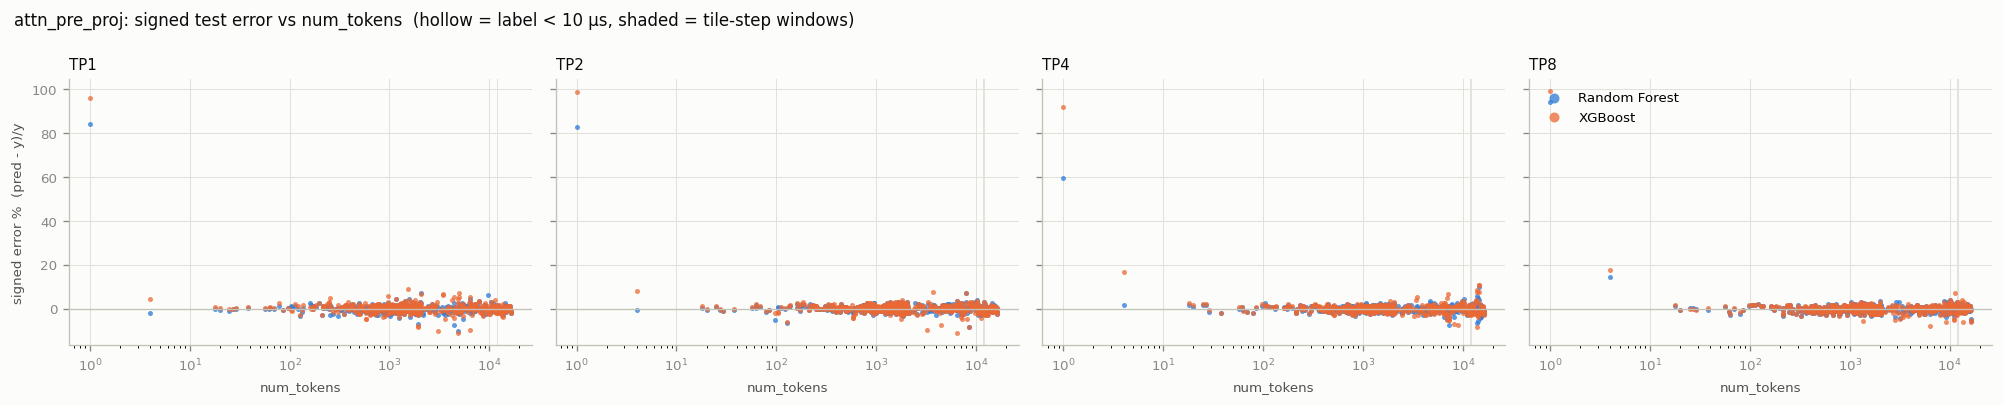

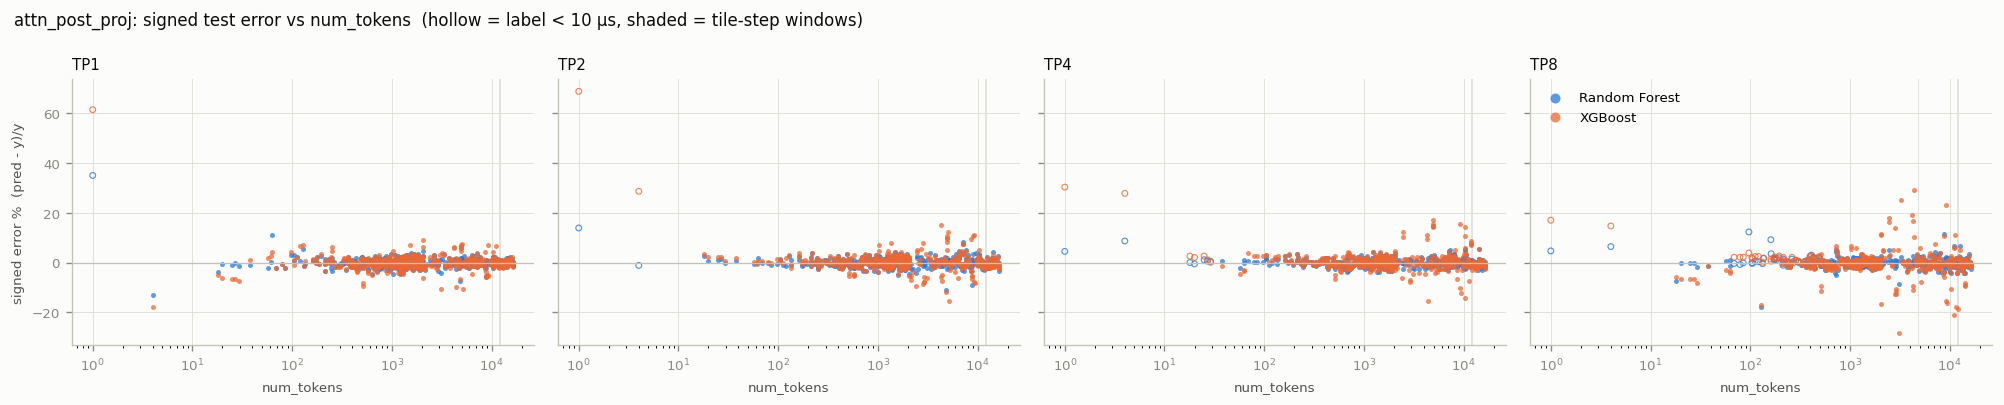

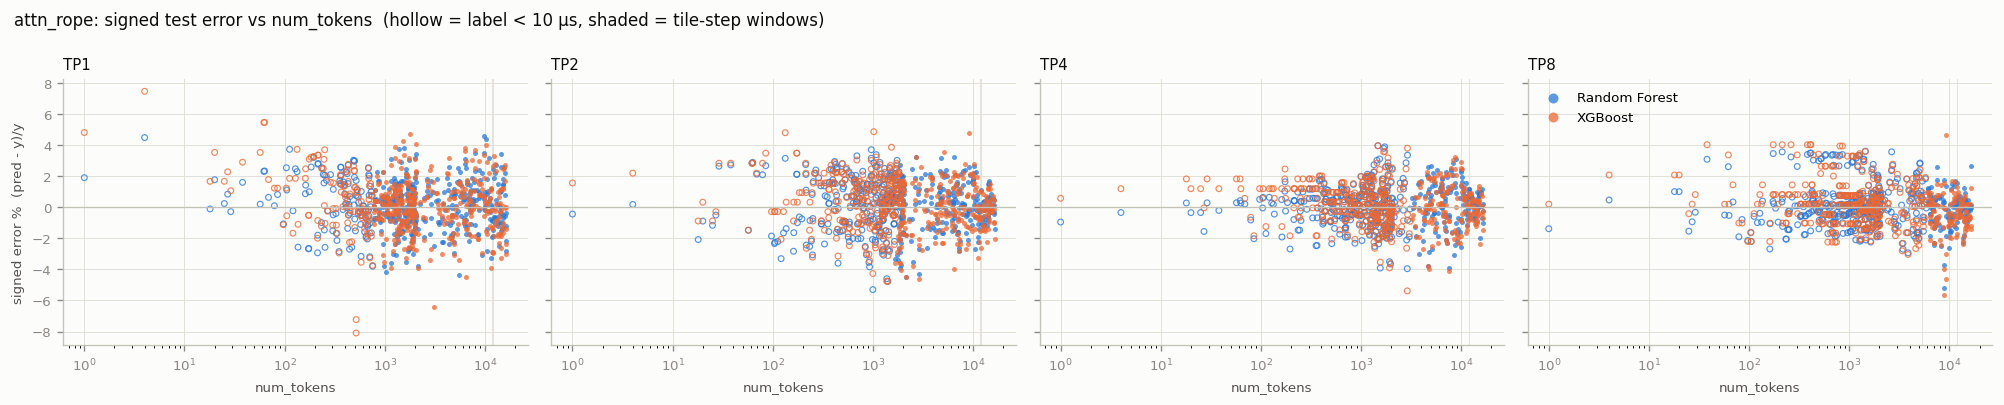

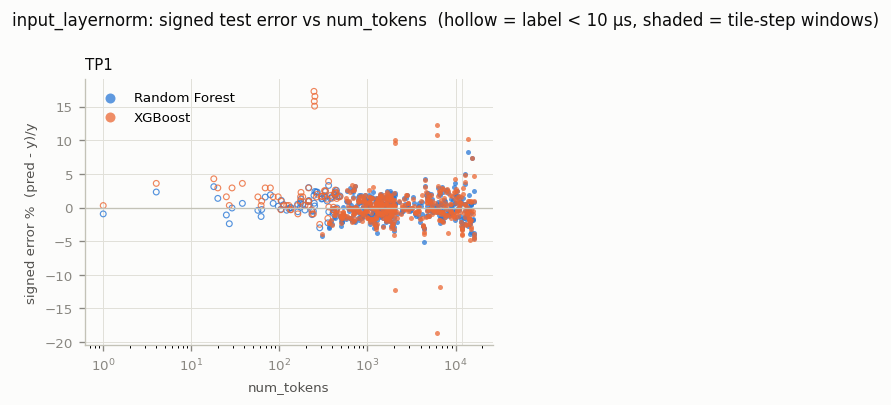

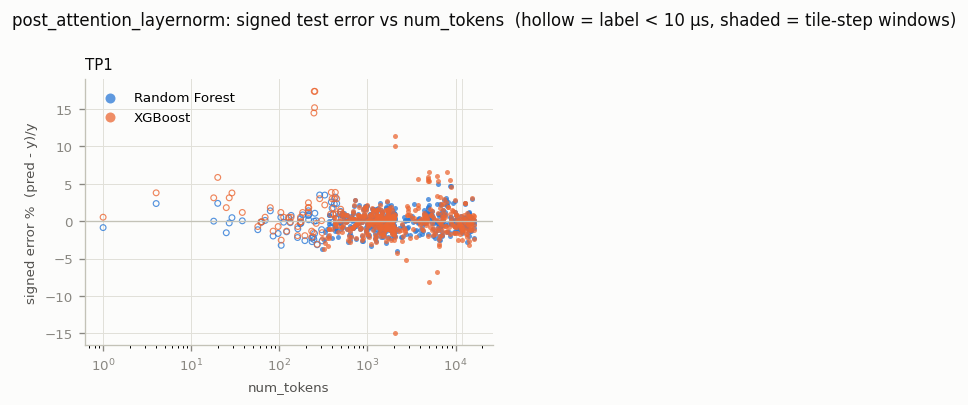

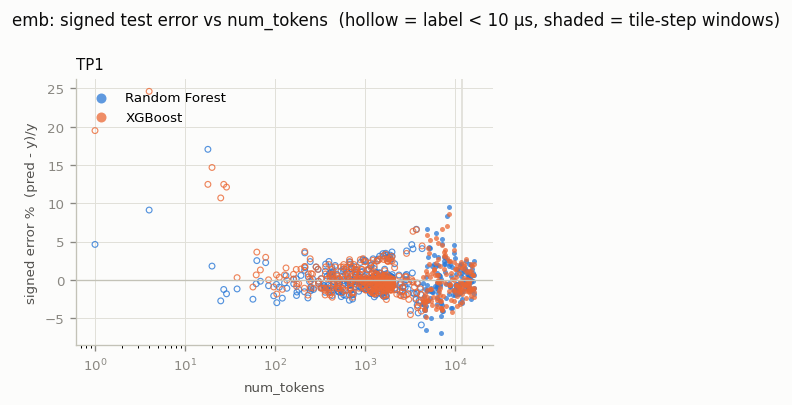

In [7]:
def signed_op(op):
    tps = sorted(preds[preds.op == op].tp.unique())
    fig, axes = plt.subplots(1, len(tps), figsize=(4.2 * len(tps), 3.4), dpi=120, sharey=True, squeeze=False)
    fig.patch.set_facecolor(SURFACE)
    for ax, tp in zip(axes[0], tps):
        style(ax)
        for lo, hi in CLIFFS: ax.axvspan(lo, hi, color=GRID, alpha=.9, lw=0)
        for m, (name, color) in MODELS.items():
            g = preds[(preds.op == op) & (preds.tp == tp) & (preds.model == m)]
            solid, hollow = g[~g.sub10us], g[g.sub10us]
            ax.scatter(solid.num_tokens, solid.signed_pct, s=9, color=color, alpha=.75, lw=0, label=name)
            ax.scatter(hollow.num_tokens, hollow.signed_pct, s=12, facecolors="none", edgecolors=color, lw=.7, alpha=.8)
        ax.axhline(0, color=BASELINE, lw=.8); ax.set_xscale("log")
        ax.set_title(f"TP{tp}", loc="left", fontsize=9, color=INK); ax.set_xlabel("num_tokens", fontsize=8, color=INK2)
    axes[0][0].set_ylabel("signed error %  (pred - y)/y", fontsize=8, color=INK2)
    axes[0][-1].legend(frameon=False, fontsize=8, loc="upper left", markerscale=2)
    fig.suptitle(f"{op}: signed test error vs num_tokens  (hollow = label < 10 µs, shaded = tile-step windows)", x=.01, ha="left", fontsize=10, color=INK)
    fig.tight_layout(); plt.show()

for op in ["attn_pre_proj", "attn_post_proj", "attn_rope", "input_layernorm", "post_attention_layernorm", "emb"]:
    signed_op(op)

## View 3: absolute error in µs vs `num_tokens`

Same points, y-axis in microseconds (log). This is the error that propagates into a layer-summed forward time.

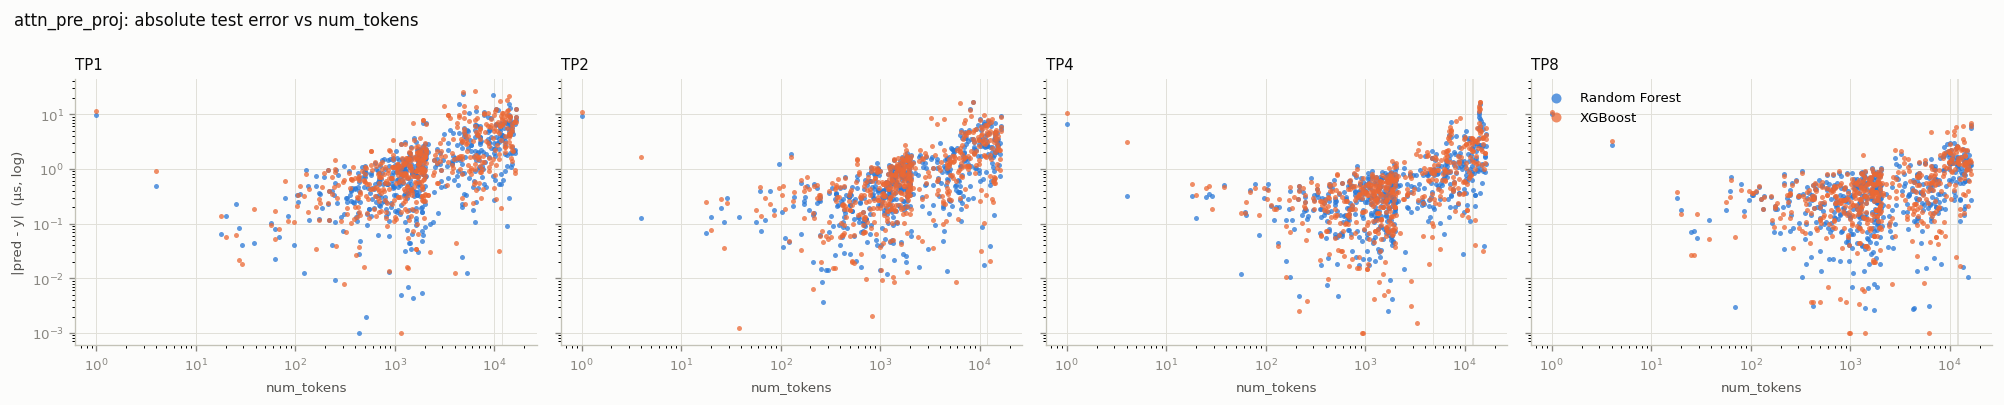

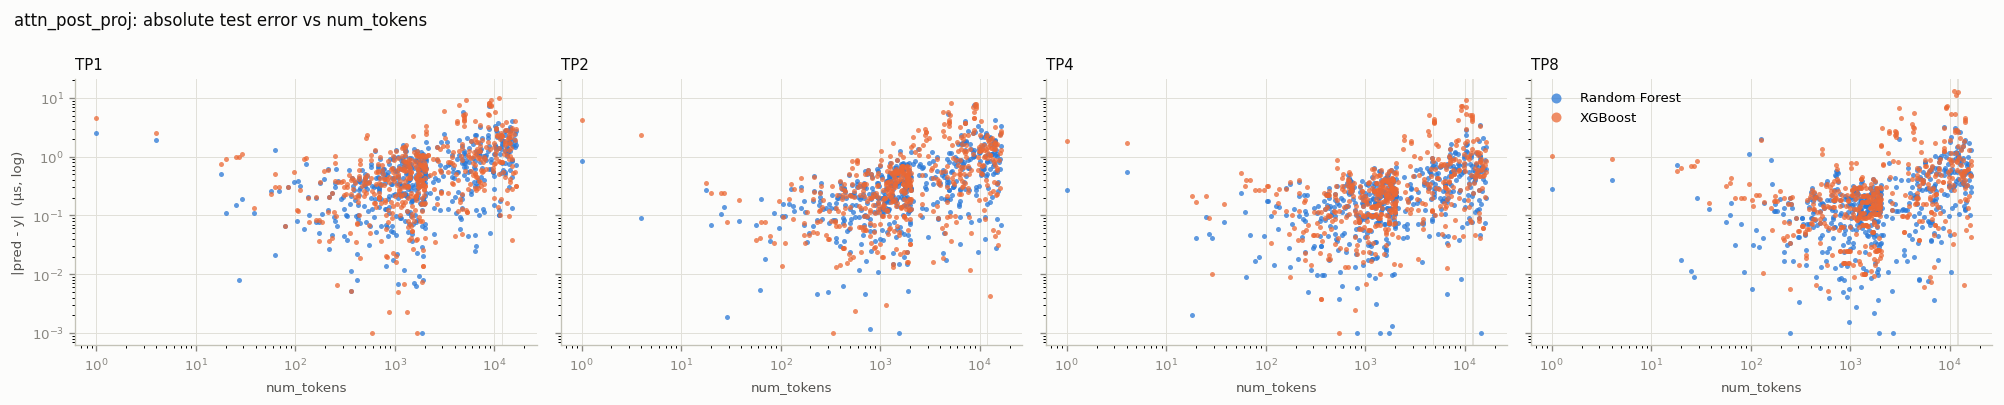

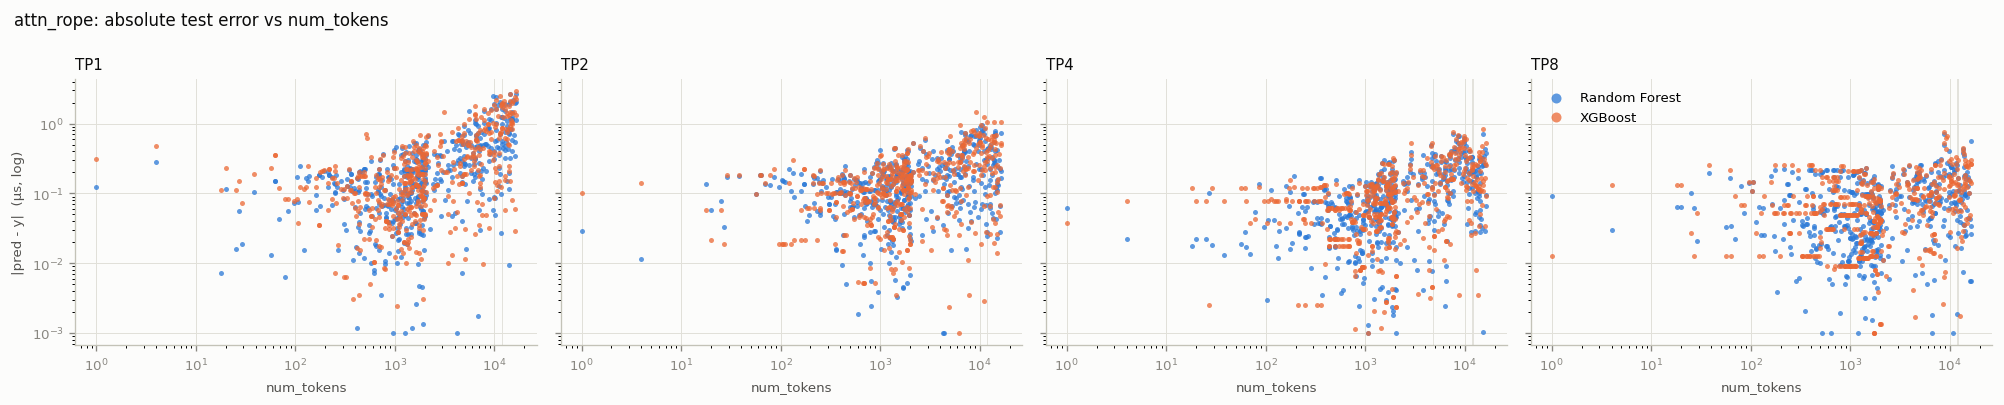

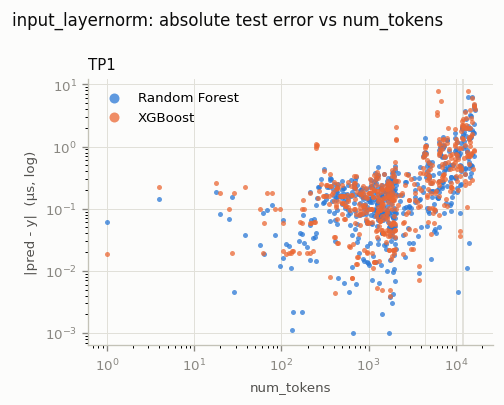

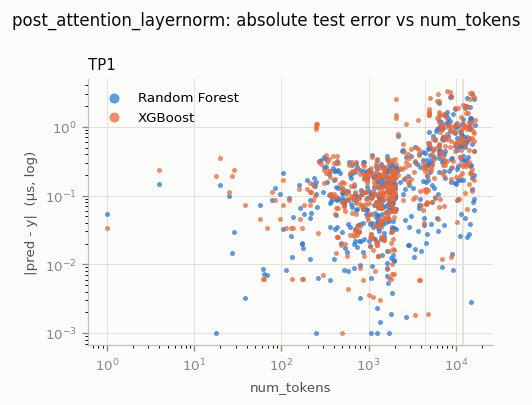

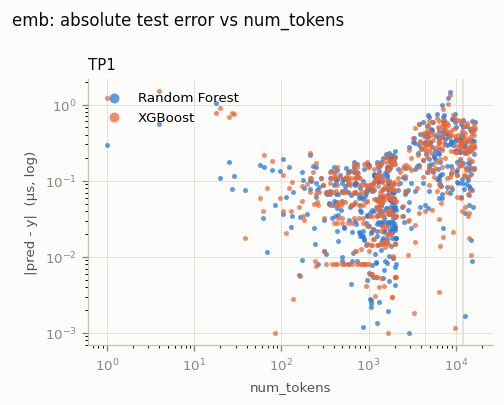

In [8]:
def abs_op(op):
    tps = sorted(preds[preds.op == op].tp.unique())
    fig, axes = plt.subplots(1, len(tps), figsize=(4.2 * len(tps), 3.4), dpi=120, sharey=True, squeeze=False)
    fig.patch.set_facecolor(SURFACE)
    for ax, tp in zip(axes[0], tps):
        style(ax)
        for lo, hi in CLIFFS: ax.axvspan(lo, hi, color=GRID, alpha=.9, lw=0)
        for m, (name, color) in MODELS.items():
            g = preds[(preds.op == op) & (preds.tp == tp) & (preds.model == m)]
            ax.scatter(g.num_tokens, g.abs_err_us.clip(lower=1e-3), s=9, color=color, alpha=.75, lw=0, label=name)
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_title(f"TP{tp}", loc="left", fontsize=9, color=INK); ax.set_xlabel("num_tokens", fontsize=8, color=INK2)
    axes[0][0].set_ylabel("|pred - y|  (µs, log)", fontsize=8, color=INK2)
    axes[0][-1].legend(frameon=False, fontsize=8, loc="upper left", markerscale=2)
    fig.suptitle(f"{op}: absolute test error vs num_tokens", x=.01, ha="left", fontsize=10, color=INK)
    fig.tight_layout(); plt.show()

for op in ["attn_pre_proj", "attn_post_proj", "attn_rope", "input_layernorm", "post_attention_layernorm", "emb"]:
    abs_op(op)

## Worst points

The ten largest relative misses per model, with the label so the µs size of the miss is visible. Recurring tokens
across ops or models point at a measurement artefact rather than a model weakness.

In [9]:
cols = ["model", "op", "tp", "num_tokens", "y_us", "pred_us", "ape", "abs_err_us", "cliff", "sub10us"]
w = preds.assign(y_us=preds.y * 1e3, pred_us=preds.pred * 1e3)
pd.concat([w[w.model == m].nlargest(10, "ape") for m in MODELS])[cols].round(2).reset_index(drop=True)

,model,op,tp,num_tokens,y_us,pred_us,ape,abs_err_us,cliff,sub10us
0,rf,attn_pre_proj,8,1,10.92,21.17,93.86,10.25,False,False
1,rf,attn_pre_proj,1,1,11.76,21.64,83.97,9.88,False,False
2,rf,attn_pre_proj,2,1,11.20,20.47,82.79,9.27,False,False
3,rf,attn_pre_proj,4,1,11.36,18.10,59.31,6.74,False,False
4,rf,attn_post_proj,1,1,7.32,9.88,34.94,2.56,False,True
5,rf,attn_post_proj,8,128,11.32,9.30,17.86,2.02,False,False
6,rf,emb,1,18,6.24,7.30,17.05,1.06,False,True
7,rf,attn_pre_proj,8,4,18.48,21.17,14.55,2.69,False,False
8,rf,attn_post_proj,2,1,6.16,7.02,13.88,0.86,False,True
9,rf,attn_post_proj,1,4,14.36,12.47,13.15,1.89,False,False


## One-glance comparison: p95 / p99 / max across all 15 regressors

Dot plots on a log axis, one row per (op, TP). The two models sit side by side, so a tail regression on one pair is
visible without scanning the table.

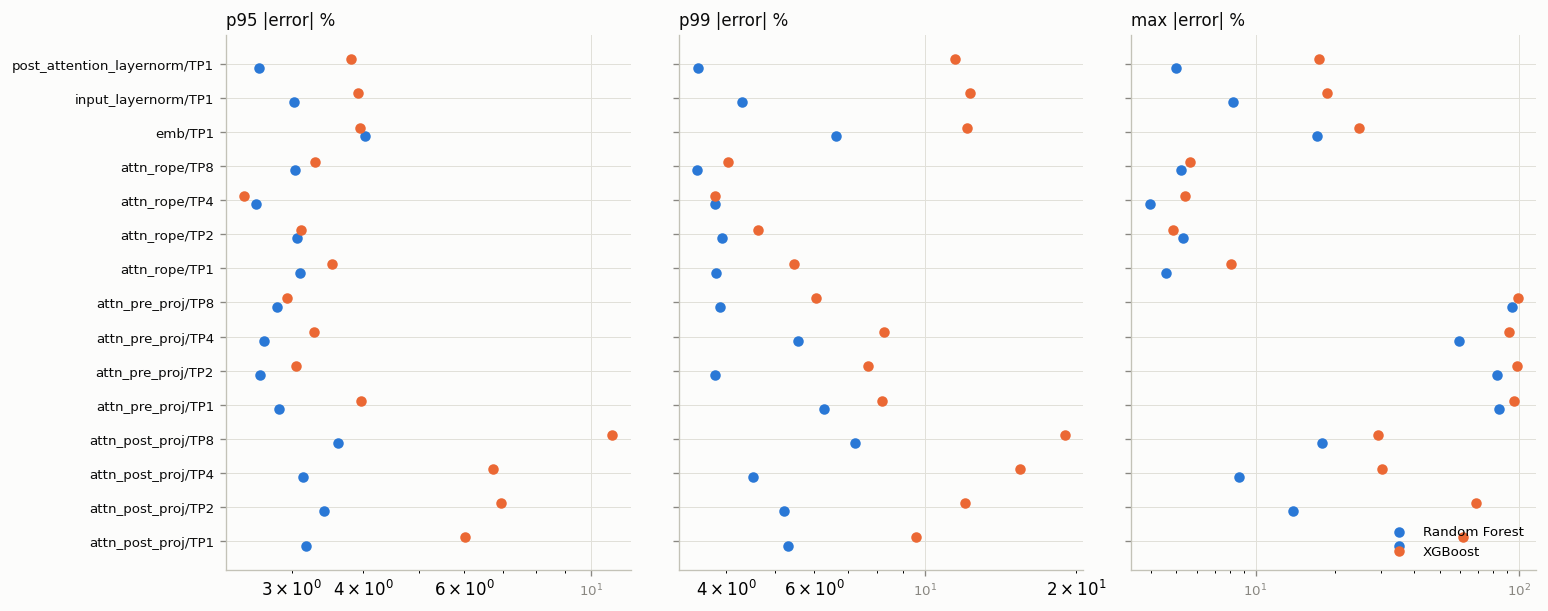

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5.2), dpi=120, sharey=True)
fig.patch.set_facecolor(SURFACE)
order = tab[tab.model == "rf"].sort_values(["op", "tp"]).apply(lambda r: f"{r.op}/TP{r.tp}", axis=1).tolist()
for ax, metric in zip(axes, ["p95", "p99", "max"]):
    style(ax); ax.set_xscale("log")
    for k, (m, (name, color)) in enumerate(MODELS.items()):
        d = tab[tab.model == m].assign(key=lambda d: d.op + "/TP" + d.tp.astype(str)).set_index("key").loc[order]
        ax.scatter(d[metric], np.arange(len(order)) + (k - .5) * .25, s=28, color=color, label=name, zorder=3)
    ax.set_title(f"{metric} |error| %", loc="left", fontsize=10, color=INK)
axes[0].set_yticks(range(len(order))); axes[0].set_yticklabels(order, fontsize=8, color=INK)
axes[-1].legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

## Notes

* Numbers here are the test tier of the sealed random-geometry split (interpolation between neighbouring grid
  points). The block-geometry results in `RESULTS_full_v1.md` are the gap-filling case and are 1-2 points worse.
* `p99` on ~499 points is the 5th-worst point; compare it with the max, not with p95, when judging stability.
* To rebuild this notebook after a new run: `python build_eval_notebook.py --execute`.